# 01 · Exploratory data analysis

**Question:** what drives the asking price of a used car, and what problems in the raw data must the
pipeline handle? Everything here is exploratory: no statistic computed in this notebook feeds a model.

> Data: ~178k Italian used-car listings (private dataset, not redistributed). If `data/raw/auto_price.csv`
> is missing the notebook falls back to a small synthetic sample so it still runs.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from car_price.config import load_config, resolve
from car_price.data import TARGET, clean, load_dataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
cfg = load_config()
FIG = resolve(cfg, "figures"); FIG.mkdir(parents=True, exist_ok=True)

raw, source = load_dataset(cfg)
print(f"source={source}  shape={raw.shape}")
raw.head(3).T.head(12)

source=raw  shape=(178248, 25)


,0,1,2
price,15500,3900,15900
MatriculationMonth,Luglio,Novembre,Giugno
MatriculationYear,2013,2006,2014
km,82914.0,161038.0,114830.0
cv,85.0,75.0,80.0
FuelType,Diesel,Benzina,Diesel
gearboxType,Cambio automatico,Cambio manuale,Cambio manuale
Consume,4.1,7.2,3.8
city,Modena,Modena,Modena
province,Modena,Modena,Modena


## Missing values
Several optional fields (interior, metallic paint, emission class, consumption) are mostly empty. Rather than dropping rows or columns, the pipeline keeps them: trees handle `NaN` natively and categoricals get an explicit `Unknown` level.

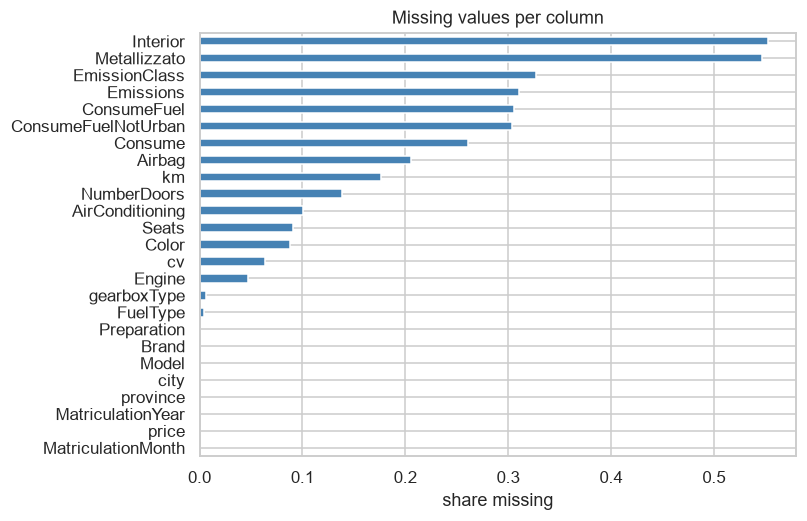

In [2]:
miss = raw.isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
miss.plot.barh(ax=ax, color="steelblue"); ax.invert_yaxis()
ax.set(xlabel="share missing", title="Missing values per column")
plt.show()

## Target: price
Price is heavily right-skewed (a few supercars), so the models are trained on `log1p(price)`; this also makes errors *relative*, which is how buyers think about a price.

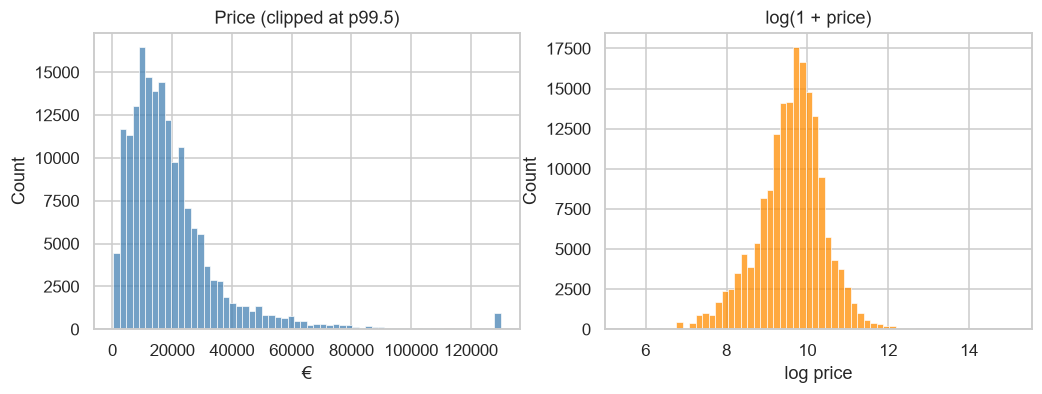

count     178248.0
mean       20262.0
std        25941.0
min          239.0
25%         9400.0
50%        15900.0
75%        24500.0
max      3500000.0
Name: price, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(raw[TARGET].clip(upper=raw[TARGET].quantile(.995)), bins=60, ax=axes[0], color="steelblue")
axes[0].set(title="Price (clipped at p99.5)", xlabel="€")
sns.histplot(np.log1p(raw[TARGET]), bins=60, ax=axes[1], color="darkorange")
axes[1].set(title="log(1 + price)", xlabel="log price")
plt.show()
print(raw[TARGET].describe().round(0))

## After cleaning
Row-level rules (duplicates, impossible years/mileage/power, data-entry errors) are in `car_price.data.clean`; see notebook 02 for the funnel.

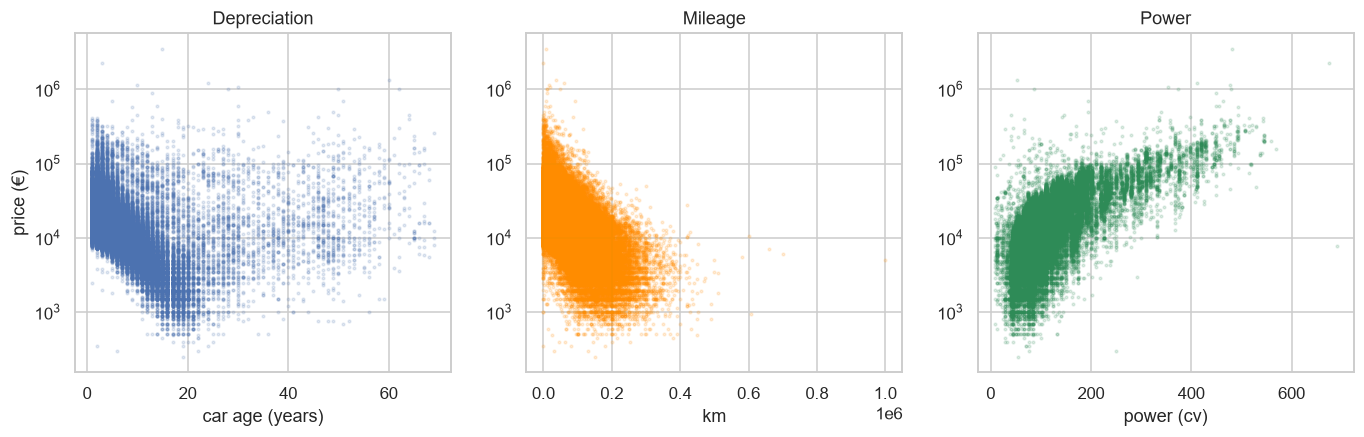

In [4]:
df = clean(raw, cfg)
age = (cfg["cleaning"]["reference_year"] - df["MatriculationYear"]).clip(lower=1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(age, df[TARGET], s=3, alpha=.15); axes[0].set(yscale="log", xlabel="car age (years)", ylabel="price (€)", title="Depreciation")
axes[1].scatter(df["km"], df[TARGET], s=3, alpha=.15, color="darkorange"); axes[1].set(yscale="log", xlabel="km", title="Mileage")
axes[2].scatter(df["cv"], df[TARGET], s=3, alpha=.15, color="seagreen"); axes[2].set(yscale="log", xlabel="power (cv)", title="Power")
plt.show()

## Brand and segment
A handful of brands hold most listings, while premium brands are rare *and* expensive: exactly where a model has least data. This motivates target-encoding `Brand`/`Model` and later reporting error per segment.

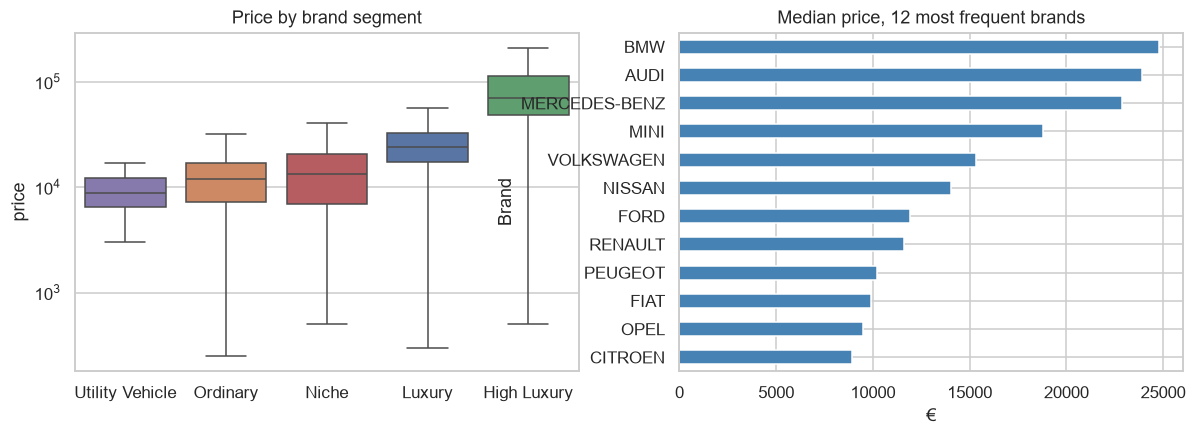

Ordinary           66984
Luxury             28836
Niche               3138
High Luxury         2222
Utility Vehicle        8
Name: count, dtype: int64


In [5]:
from car_price.features import FeatureBuilder
fb = FeatureBuilder(reference_year=cfg["cleaning"]["reference_year"]).fit(df)
seg = fb._segment(df["Brand"], df["Seats"])
order = df.groupby(seg)[TARGET].median().sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x=seg, y=df[TARGET], order=order, ax=axes[0], showfliers=False, hue=seg, legend=False)
axes[0].set(yscale="log", xlabel="", title="Price by brand segment")
top = df["Brand"].value_counts().head(12).index
med = df[df["Brand"].isin(top)].groupby("Brand")[TARGET].median().sort_values()
med.plot.barh(ax=axes[1], color="steelblue"); axes[1].set(title="Median price, 12 most frequent brands", xlabel="€")
plt.show()
print(seg.value_counts())

## Correlations
Mileage-related features are strongly collinear (`km`, `car_age`, `avg_km_per_year`), which hurts plain linear models but not trees. That is one reason the model zoo mixes regularised linear models and boosted trees.

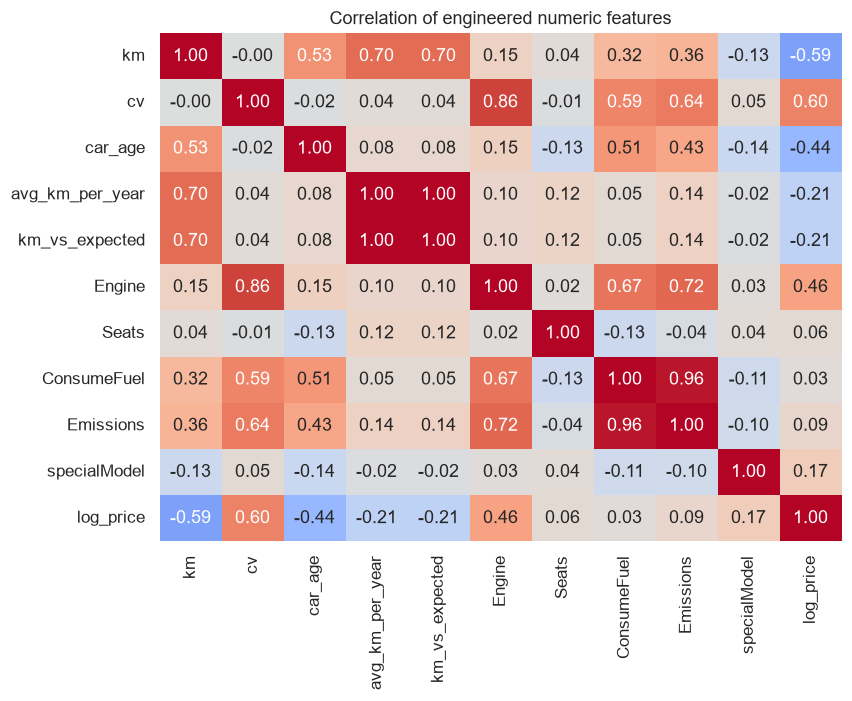

In [6]:
num = fb.transform(df)
num = num.select_dtypes("number").assign(log_price=np.log1p(df[TARGET]))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar=False)
ax.set_title("Correlation of engineered numeric features")
plt.show()